In [1]:
from google.colab import files
uploaded = files.upload()

Saving movies.csv to movies.csv
Saving ratings.csv to ratings.csv



Item-User Matrix Shape: (9066, 671)

Item Similarity Matrix:
 movieId         1         2         3         4         5
movieId                                                  
1        1.000000  0.394511  0.306516  0.133614  0.245102
2        0.394511  1.000000  0.217492  0.164651  0.278476
3        0.306516  0.217492  1.000000  0.177012  0.370732
4        0.133614  0.164651  0.177012  1.000000  0.179556
5        0.245102  0.278476  0.370732  0.179556  1.000000

Recommended Movies (Item-Based):

      movieId                                   title
1020     1266                       Unforgiven (1992)
1114     1374  Star Trek II: The Wrath of Khan (1982)
1665     2105                             Tron (1982)
1771     2243                   Broadcast News (1987)
2396     2985                          RoboCop (1987)

RMSE (Item-Based): 0.993
Precision@5: 0.2


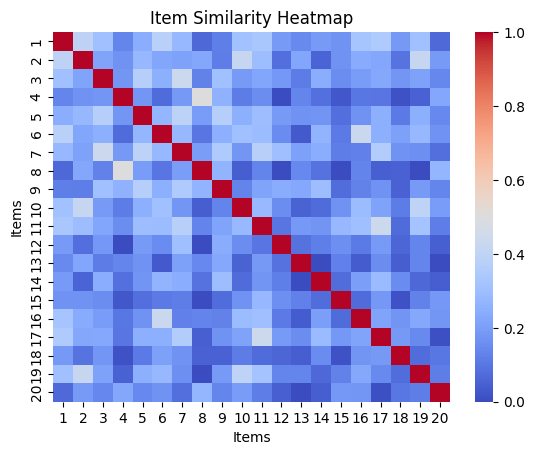

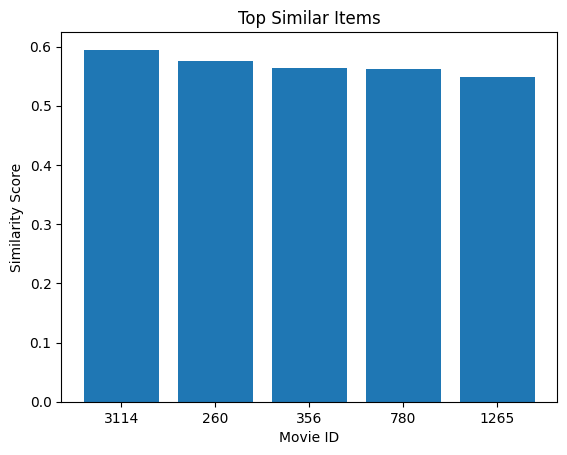

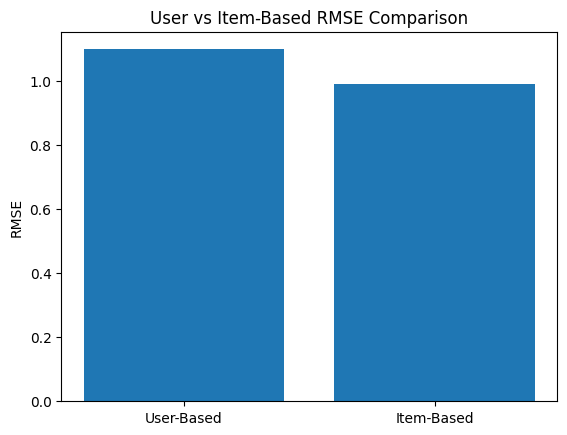

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

item_user = ratings.pivot(index='movieId', columns='userId', values='rating')
item_user_filled = item_user.fillna(0)

print("\nItem-User Matrix Shape:", item_user.shape)

item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_user.index,
                                  columns=item_user.index)

print("\nItem Similarity Matrix:\n", item_similarity_df.iloc[:5, :5])

def get_similar_items(movie_id, n=5):
    sim_scores = item_similarity_df[movie_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(movie_id)
    return sim_scores.head(n)

def recommend_items(user_id, n=5):
    user_ratings = ratings[ratings['userId'] == user_id]
    scores = {}

    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']

        similar_movies = get_similar_items(movie, n=10)

        for sim_movie, sim_score in similar_movies.items():
            if sim_movie not in scores:
                scores[sim_movie] = 0
            scores[sim_movie] += sim_score * rating

    sorted_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommended_ids = [i[0] for i in sorted_movies[:n]]

    return movies[movies['movieId'].isin(recommended_ids)][['movieId', 'title']]

user_id = 1

print("\nRecommended Movies (Item-Based):\n")
print(recommend_items(user_id, 5))

actual = []
predicted = []

for user in ratings['userId'].unique()[:50]:
    user_data = ratings[ratings['userId'] == user]

    for _, row in user_data.iterrows():
        movie = row['movieId']
        true_rating = row['rating']

        similar_items = get_similar_items(movie, n=10)

        pred = 0
        total_sim = 0

        for sim_movie, sim_score in similar_items.items():
            if not np.isnan(item_user.loc[sim_movie, user]):
                pred += sim_score * item_user.loc[sim_movie, user]
                total_sim += abs(sim_score)

        if total_sim != 0:
            pred /= total_sim
        else:
            pred = item_user.mean().mean()

        actual.append(true_rating)
        predicted.append(pred)

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE (Item-Based):", round(rmse, 3))

def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, k)
    recommended_ids = recommended['movieId'].values

    actual_movies = ratings[(ratings['userId'] == user_id) & (ratings['rating'] >= 4)]['movieId'].values

    relevant = set(recommended_ids).intersection(set(actual_movies))
    return len(relevant) / k

precision = precision_at_k(user_id, 5)
print("Precision@5:", round(precision, 3))

plt.figure()
sns.heatmap(item_similarity_df.iloc[:20, :20], cmap='coolwarm')
plt.title("Item Similarity Heatmap")
plt.xlabel("Items")
plt.ylabel("Items")
plt.show()

movie_id = 1
similar_items = get_similar_items(movie_id, 5)

plt.figure()
plt.bar(similar_items.index.astype(str), similar_items.values)
plt.title("Top Similar Items")
plt.xlabel("Movie ID")
plt.ylabel("Similarity Score")
plt.show()

user_rmse = 1.1

plt.figure()
models = ['User-Based', 'Item-Based']
values = [user_rmse, rmse]
plt.bar(models, values)
plt.title("User vs Item-Based RMSE Comparison")
plt.ylabel("RMSE")
plt.show()